Nome: Vinícius Barbosa Bassete

RA: 248135

Curso: Mestrado em Física Aplicada



# Ex05 - Classificação de imagens usando rede neural convolucional (CNN)

O objetivo principal deste notebook é ilustrar e praticar o uso de redes neurais convolucionais (CNNs) para tarefas de classificação de imagens. Em relação às redes neurais convencionais, as CNNs geralmente apresentam a vantagem de possuir menos parâmetros a serem aprendidos. Além disso, as CNNs são particularmente adequadas para trabalhar com imagens devido à sua arquitetura projetada para lidar com dados espaciais de forma eficiente.

Tomaremos como base a biblioteca PyTorch, que segue uma abordagem de programação orientada a objetos. Além dela, recomendamos o uso de outras bibliotecas relacionadas (como o PyTorch Lightning) que auxiliam e simplificam etapas do framework. Note que algumas destas bibliotecas podem não estar disponíveis por padrão no Colab ou sua máquina, sendo necessária sua instalação (como exemplificado na próxima célula de código).

Para mais informações sobre redes convolucionais, exemplos e boas práticas, recomendamos os materiais de apoio às aulas 5 e 6 disponibilizados no classroom. Lá você vai encontrar um tutorial teórico sobre CNN, além de tutoriais práticos disponibilizados no GitHub, vídeos e links de apoio. Em especial, o tutorial prático de classificação com CNN ([link](https://colab.research.google.com/drive/1uXLYbWwHT8cChAYmexV6QNUi5eI4ITod?usp=sharing)) pode ser de grande ajuda.

**Atenção!** Não se esqueça de utilizar a GPU do Colab (clique em "Ambiente de execução" e "Alterar o tipo de ambiente de execução", selecione a GPU).

In [ ]:
# Instalando bibliotecas
!pip install pytorch-lightning torchinfo torchmetrics torch-summary torchmetrics medmnist tensorboard

In [ ]:
# Importando as bibliotecas que serão utilizadas
import multiprocessing as mp
import os
import random
import sys
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import torchinfo
from medmnist import DermaMNIST
from pytorch_lightning.callbacks import ModelCheckpoint
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset
from torchmetrics import Accuracy
from torchsummary import summary
from torchvision import datasets, models
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid

%load_ext tensorboard

In [2]:
torch.set_float32_matmul_precision('medium')

## Parte 1 - Exemplo de classificação com o MNIST

Exemplificaremos algumas das etapas do framework de classificação com CNN utilizando o conjunto de dados MNIST (Modified National Institute of Standards and Technology database), um grande conjunto de dados de dígitos manuscritos comumente usado na área de aprendizado de máquina. Ele consiste de 60.000 imagens de treinamento e 10.000 images de teste (que, no nosso exemplo, serão utilizadas para validação). As imagens do conjunto são de 28x28 pixels. Uma descrição completa do conjunto de dados pode ser encontrada [aqui](https://en.wikipedia.org/wiki/MNIST_database).

### Leitura dos dados

Idealmente, códigos para processar amostras de dados devem estar desacoplados do código do treinamento do modelo, facilitando sua legibilidade e modularidade. O PyTorch fornece duas primitivas de dados ([torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) e [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset)) que facilitam a leitura, processamento e organização dos dados para entrada no modelo. Mais informações sobre Datasets e DataLoaders podem ser encontradas [aqui](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) e [aqui](https://blog.paperspace.com/dataloaders-abstractions-pytorch/).

In [3]:
# Carregando os dados utilizando torchvision.datasets e convertendo as imagens para tensores
training_data = datasets.MNIST(
    root="data_mnist",
    train=True,
    download=True,
    transform=ToTensor()
)
val_data = datasets.MNIST(
    root="data_mnist",
    train=False,
    download=True,
    transform=ToTensor()
)

print(training_data)
print()
print(val_data)
print()
print("*Note que, apesar de identificado como teste, utilizaremos o segundo conjunto de dados para validação!")

Dataset MNIST
    Number of datapoints: 60000
    Root location: data_mnist
    Split: Train
    StandardTransform
Transform: ToTensor()

Dataset MNIST
    Number of datapoints: 10000
    Root location: data_mnist
    Split: Test
    StandardTransform
Transform: ToTensor()

*Note que, apesar de identificado como teste, utilizaremos o segundo conjunto de dados para validação!


**É sempre importante checar e visualizar os dados a cada etapa do framework de classificação, garantindo que eles estão de acordo com o esperado e evitando a propagação de erros.**

2
<class 'torch.Tensor'> <class 'int'>
Shape da imagem: torch.Size([1, 28, 28])
Label: 8
Maior valor de intensidade da imagem: tensor(1.)
Menor valor de intensidade da imagem: tensor(0.)


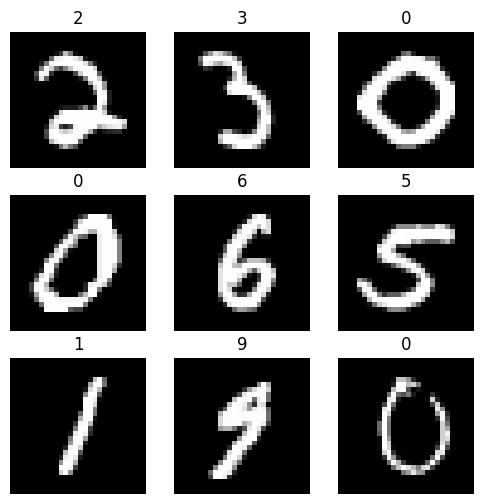

In [5]:
# Checando informações de uma amostra de treinamento
training_example = random.choice(training_data)
print(len(training_example))
print(type(training_example[0]), type(training_example[1]))
print('Shape da imagem:', training_example[0].shape)
print('Label:', training_example[1])
print('Maior valor de intensidade da imagem:', torch.max(training_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(training_example[0]))

# Visualizando algumas imagens e labels do conjunto de treinamento
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(training_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.show()

2
<class 'torch.Tensor'> <class 'int'>
Shape da imagem: torch.Size([1, 28, 28])
Label: 4
Maior valor de intensidade da imagem: tensor(1.)
Menor valor de intensidade da imagem: tensor(0.)


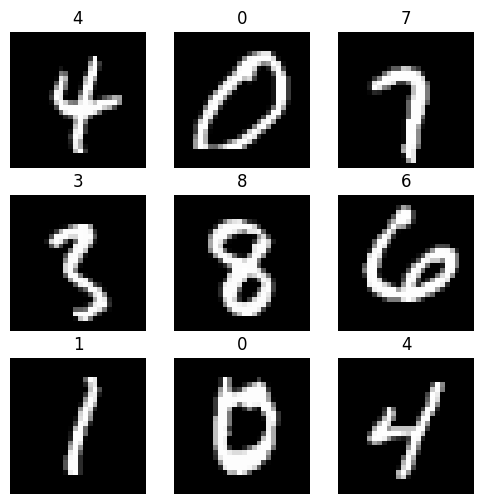

In [4]:
# Checando informações de uma amostra de validação
val_example = random.choice(val_data)
print(len(val_example))
print(type(val_example[0]), type(val_example[1]))
print('Shape da imagem:', val_example[0].shape)
print('Label:', val_example[1])
print('Maior valor de intensidade da imagem:', torch.max(val_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(val_example[0]))

# Visualizando algumas imagens e labels do conjunto de validação
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(val_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.show()

### Exercício 1.1

Explique o processamento aplicado pela classe torchvision.transforms.ToTensor às imagens do conjunto. Explique também porque foi necessário utilizar o .squeeze() para visualizar as imagens e qual a sua função.

RESPOSTA: Explique o processamento aplicado pela classe torchvision.transforms.ToTensor às imagens do conjunto. Explique também porque foi necessário utilizar o .squeeze() para visualizar as imagens e qual a sua função.

RESPOSTA:
A função torchvision.transforms.ToTensor() converte a imagem/ndarray de formato [H,W,C] e range (0,255) para um tensor do pytorch de formato [C,H,W] e range (0,1). Quando a imagem foge do range (0,255) não é realizada nenhuma modificação nos valores de pixel.

O método squeeze() remove uma dimensão do tensor, portanto o tensor original de shape [1,28,28] vira um tensor de tamanho [28,28]

### Hiperparâmetros

É interessante utilizar um dicionário de hiperparâmetros para organizar o código, evitar "números mágicos" e registrar as configurações de cada experimento realizado.

In [5]:
hparams = {"experiment_name": "Test_ResNet_1",  # experiment name identifies the run for later
           "max_epochs": 10,  # number of epochs to train
           "batch_size": 100,  # size of batch
           "nworkers": 0 if sys.platform.startswith("win") else mp.cpu_count(),  # number of workers to use in parallel loading
           "nout": 10,  # number of classes
           "nin": 1,  # number of channels of the input image
           "lr": 1e-4,  # learning rate
           "wd": 1e-5,  # weight decay for optimizer
           "cpu": False,  # forces using the CPU
           }

for k, v in hparams.items():
    print(f"{k}: {v}")

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 100
nworkers: 32
nout: 10
nin: 1
lr: 0.0001
wd: 1e-05
cpu: False


### Data Module

A classe [pytorch_lightning.LightningDataModule](https://lightning.ai/docs/pytorch/stable/data/datamodule.html) pode ser utilizada para organizar os DataLoaders e os dados.

In [6]:
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)

    def setup(self, stage=None):
        self.train = training_data
        self.val = val_data

    '''
    Dataloaders optimize data loading and automatically prepare batches
    '''
    def train_dataloader(self):
        return DataLoader(self.train, 
                            batch_size=self.hparams.batch_size, 
                            num_workers=self.hparams.nworkers, 
                            shuffle=True,
                            persistent_workers=True,
                            pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val, 
                          batch_size=self.hparams.batch_size, 
                          num_workers=self.hparams.nworkers, 
                          shuffle=False,
                          persistent_workers=True,
                          pin_memory=True)

**Novamente, checamos os dados obtidos através do DataModule.**

Shape do batch: torch.Size([100, 1, 28, 28])


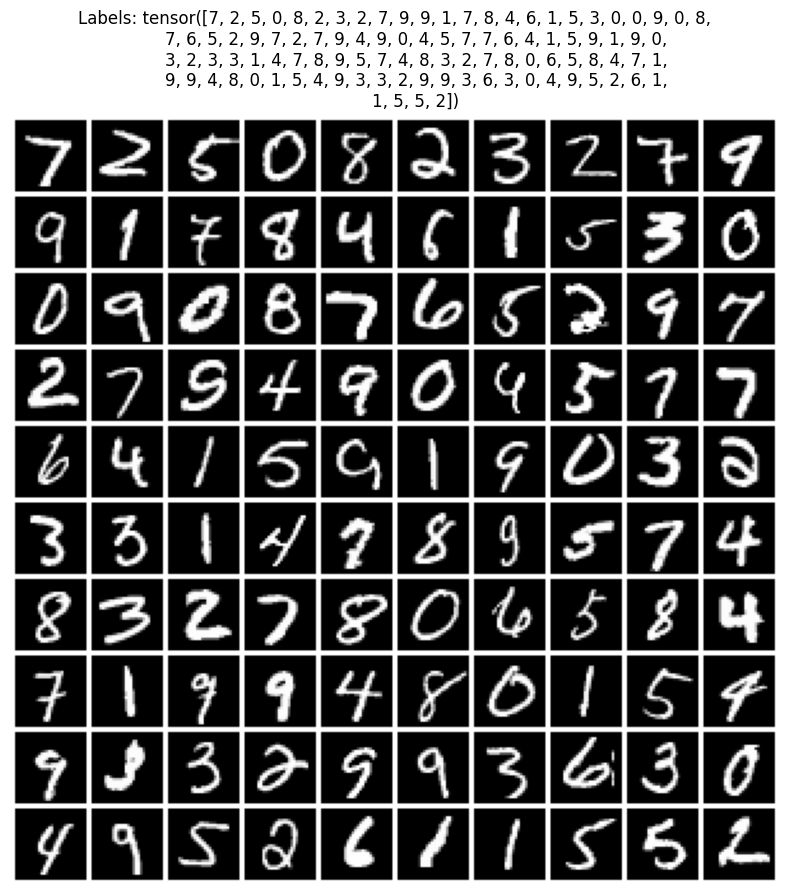

In [7]:
# DEBUG DATA MODULE
data_module = MNISTDataModule(hparams)
data_module.setup()

check_dataloader = data_module.train_dataloader() # dataloader do treino
img_batch, label_batch = next(iter(check_dataloader))
print("Shape do batch:", img_batch.shape)

img_grid = make_grid(img_batch, nrow=10, pad_value=1)
fig = plt.figure(figsize=(10,10))
plt.imshow(img_grid.permute(1, 2, 0).numpy())
plt.title(f'Labels: {label_batch}')
plt.axis('off')
plt.show()




### Definindo a CNN

No código abaixo, é criado um modelo baseado na [Resnet-18](https://pytorch.org/vision/master/models/generated/torchvision.models.resnet18.html). O mesmo será treinado **sem transfer learning** e com uma inicialização randômica dos pesos. Visualizamos também todas as camadas (layers) que compõem o modelo e seus parâmetros.

In [8]:
cnn_model = models.resnet18(weights=None)
print(cnn_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
cnn_model.conv1 = nn.Conv2d(hparams['nin'], 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
num_ftrs = cnn_model.fc.in_features
cnn_model.fc = nn.Linear(num_ftrs, hparams['nout'])
print(cnn_model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Exercício 1.2

Para que serve cada camada da rede? Por que foi necessário modificar ligeiramente a rede (célula anterior) e que modificações foram realizadas?

RESPOSTA:
Com o output da celula acima, idenfitifiquei alguns tipos de camadas:
- Conv2D: Aplica a operação de convolução entre a entrada e os filtros existentes na camada.
- Batchnorm: normalizam a saída numérica da camada anterior, ajudando a estabilizar o treino, evitando que os valores numéricos cresçam demais.
- relu: aplica uma função não linear, trazendo complexidade a rede, transforma todos os inputs negativos em 0 e mantem os positivos.
- maxpool: reduz a dimensão da imagem de entrada utilizando com base o valor máximo de um pixel em uma vizinhança.
- avgpool: reduz a dimensão da imagem de entrada utilizando com base o valor médio dos pixels em uma vizinhança.
- Linear: Conecta todas os neuronios da camada anterior com os neuronios de saida através de uma transformação linear. 


Modificou-se a rede para ajustar a entrada de dados ao problema. Assim, deixamos apenas um canal para a imagem de input, filtros com kernel 7x7, stride para a operação de convolução (2,2), e padding (3,3) para as imagens.
Além disso, modificou-se o tamanho da saida da rede para 10, representando os 10 possíveis dígitos.

### Resumo do modelo

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
cnn_model.to(device)
summary(cnn_model, (1, 28, 28))

cuda:0


RuntimeError: Failed to run torchsummary. See above stack traces for more details. Executed layers up to: []

### Exercício 1.3

Tente entender as dimensões da saída de cada camada da rede. Por exemplo, porque as três primeiras camadas possuem saídas com dimensões (-1, 64, 14, 14) e a quarta camada tem saída com dimensões (-1, 64, 7, 7)?

E quanto aos parâmetros a serem aprendidos, você consegue explicar como eles são calculados?

RESPOSTA:
As três primeiras camadas (Conv2D, BatchNorm2D e ReLU) realizam operações que, conforme configuradas, podem não reduzir o tamanho da imagem. Já a camada MaxPool2D realiza uma operação de pooling, que tem a intenção de reduzir o tamanho da imagem (nesse caso, escolhendo o pixel de maior valor em uma vizinhança), e portanto está reduzindo o tamanho da imagem pela metade.

Para camadas de convolução, número de parâmetros a serem aprendidos por cada camada, se dá pelo tamanho do kernel do filtro (ex: 7x7) e pelo número de canais da imagem de entrada e de saida, por exemplo, na primeira camada, recebemos uma imagem de uma dimensão, passamos filtros 7x7 e temos como saída uma imagem de 64 canais, portanto temos 1* 7^2 * 64 = 3.136 parametros. Para as camadas de batchnormalization, temos apenas dois parametros por canal, portanto o número de parametros é o dobro do número de canais na imagem. 

### Lightning Module

Aqui definimos o comportamento durante o treinamento, ou seja, o que acontece com um lote retornado pelo DataLoader.

In [10]:
class TrainMNIST(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()

        self.save_hyperparameters(hparams)
        self.model = cnn_model
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)

        torchinfo.summary(self.model)

    def forward(self, x):
        return self.model(x).softmax(dim=-1)

    def classification_step(self, mode, batch):
        x, y = batch
        y_hat = self.forward(x)
        loss = self.loss(y_hat, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            _, preds = torch.max(y_hat, 1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step("train", train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step("val", val_batch)

    def configure_optimizers(self):
        optimizer = AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)

        return optimizer

### Treinando a CNN

In [15]:
debug = False  # Turn this True to test the code with a quick run

# Initialization
model = TrainMNIST(hparams)
data = MNISTDataModule(hparams)

# The PL trainer can run various callbacks during training. Here we only use the
# callback that saves the weights of the trained network.
os.makedirs("logs", exist_ok=True)
checkpoint_callback = [ModelCheckpoint(dirpath="logs",  # path to save checkpoint
                                       filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
                                       monitor="val_acc",
                                       mode="max")]

trainer = pl.Trainer(max_epochs=hparams["max_epochs"], #devices=1, accelerator="gpu",
                     fast_dev_run=debug,
                     callbacks=checkpoint_callback,
                     log_every_n_steps=1
                     )

print("Hyperparameters:\n")
for k, v in hparams.items():
    print(f'{k}: {v}')

trainer.fit(model, data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/vinicius/.conda/envs/ML_Env/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Hyperparameters:

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 100
nworkers: 32
nout: 10
nin: 1
lr: 0.0001
wd: 1e-05
cpu: False


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ ResNet             │ 11.2 M │ train │     0 │
│ 1 │ loss     │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 70                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


### Visualizando os logs de treinamento

Por padrão, o Pytorch Lightning registra os resultados do treinamento usando o TensorBoard. Você pode configurar muitos outros registradores (https://pytorch-lightning.readthedocs.io/en/stable/extensions/logging.html), recomendamos verificar o Neptune ou o MLFlow. Utilize esses registradores para comparar experimentos!

Abaixo é possível verificar os resultados do treinamento realizado previamente (disponibilizado no diretório **Dados/Ex05/saved_lightning_logs**).

### Análise dos resultados

Após o treinamento da rede, é importante checar os resultados de validação, visualizando algumas saídas da rede e obtendo métricas de classificação. Abaixo exemplificamos a visualização da matriz de confusão.

In [11]:
%tensorboard --logdir lightning_logs # não funciona, vou tentar rodar o código novamente depois

Reusing TensorBoard on port 6006 (pid 27025), started 9:17:28 ago. (Use '!kill 27025' to kill it.)

In [12]:
# WARNING: This will load a random checkpoint from the logs folder, if you want an specific one change it!
baseline_model = random.choice(glob("logs/*.ckpt"))
print(f"Using model {baseline_model}")

# Load trained model
model = TrainMNIST.load_from_checkpoint(baseline_model).eval().cuda()

# Initialize validation data
data = MNISTDataModule(hparams)
data.setup()
data.hparams.batch_size = 1
val_data = data.val_dataloader()

def collect_2d_results(data, model):
    y_trues = []
    y_labels = []
    for (img, label) in data:
        with torch.no_grad():
            out = model(img.cuda()).argmax(dim=-1).item()
        
        label = label.numpy()
        y_trues.append(label)
        y_labels.append(out)

    return y_trues, y_labels

y_trues_val, y_labels_val = collect_2d_results(val_data, model)

Using model logs/Test_ResNet_1-epoch=9-val_acc=0.99.ckpt


/home/vinicius/.conda/envs/ML_Env/lib/python3.12/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


RuntimeError: Error(s) in loading state_dict for TrainMNIST:
	size mismatch for model.conv1.weight: copying a param with shape torch.Size([64, 1, 7, 7]) from checkpoint, the shape in current model is torch.Size([64, 3, 7, 7]).
	size mismatch for model.fc.weight: copying a param with shape torch.Size([10, 512]) from checkpoint, the shape in current model is torch.Size([1000, 512]).
	size mismatch for model.fc.bias: copying a param with shape torch.Size([10]) from checkpoint, the shape in current model is torch.Size([1000]).

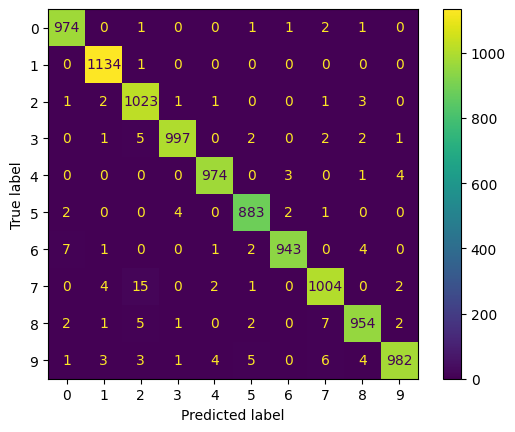

In [22]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_trues_val, y_labels_val, labels=np.arange(10)),
                                display_labels=np.arange(10))
fig = disp.plot(ax=None).figure_
plt.show()

Por fim, o modelo final seria avaliado em um conjunto de teste (que não está disponível no exemplo apresentado). **Vale ressaltar que o conjunto de teste não deve ser utilizado para refinar o modelo! Ele deve ser utilizado apenas para uma avaliação final do modelo.**

## Parte 2 - Classificação com o DermaMNIST

Vamos retomar a classificação do dataset de imagens dermatoscópicas de lesões de pele comuns, utilizado no Exercício 02. Desta vez, ao invés de extrair os atributos "artesanalmente" e classificar com o KNN, utilizaremos CNNs para realizar os dois processos simultaneamente (extração de atributos + classificação).

**Dataset**

O dataset consiste em 600 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 300 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 300 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe), um conjunto de validação com 100 imagens (50 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe). As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

### Exercício 2.1

Com base no exemplo apresentado e nos materiais de apoio disponibilizados, treine uma CNN para classificar as lesões de pele. Considere as recomendações abaixo:

- Considere aplicar [transformações](https://pytorch.org/vision/stable/transforms.html) durante a leitura dos dados, seja para normalizá-los ou realizar aumentação de dados.
- Lembre-se de sempre checar os dados!
- Você pode definir sua própria rede ou utilizar modelos de classificação disponibilizados pelo PyTorch (como a [ResNet](https://pytorch.org/vision/stable/models/resnet.html) ou a [EfficientNet](https://pytorch.org/vision/stable/models/efficientnet.html)). Caso utilize modelos disponibilizados, tome cuidado com as entradas e saídas da rede, talvez seja necessário realizar algumas modificações (como no exemplo apresentado). Considere também a utilização de modelos pré-treinados, eles apresentam resultados melhores do que modelos inicializados com pesos randômicos?
- Note que, no exemplo apresentado, os checkpoints da rede e os logs do PyTorch Lightning ficam salvos no ambiente de execução do Colab. Tome cuidado para não acabar perdendo experimentos! Você pode alterar o local em que esses arquivos são salvos para que sejam armazenados no seu Drive ou ainda salvar manualmente os arquivos que julgar importantes.
- Tente modificar os hiperparâmetros para obter melhores resultados de validação.
- Verifique os resultados do modelo: visualize algumas saídas da rede e obtenha métricas de classificação (acurácia, precisão, revocação e F1-score), além de imprimir a matriz de confusão.
- Idealmente, você deve avaliar apenas o modelo final no conjunto de teste.

Comente os métodos utilizados e resultados obtidos, tentando justificar as decisões que foram tomadas. Compare também os resultados obtidos através da CNN com os resultados obtidos através do KNN no Exercício 02.

In [13]:
#Código base para leitura dos dados

train_dataset_base = DermaMNIST(
    split="train",
    download=True
)

test_dataset_base = DermaMNIST(
    split="test",
    download=True
)

#Train+Val
train_indices_0 = train_dataset_base.labels == 1
train_indices_1 = train_dataset_base.labels == 4

train_imgs_0 = train_dataset_base.imgs[train_indices_0.flatten(), :, :, :][:200]
train_imgs_1 = train_dataset_base.imgs[train_indices_1.flatten(), :, :, :][:200]
train_imgs = np.vstack([train_imgs_0, train_imgs_1])

val_imgs_0 = train_dataset_base.imgs[train_indices_0.flatten(), :, :, :][200:250]
val_imgs_1 = train_dataset_base.imgs[train_indices_1.flatten(), :, :, :][200:250]
val_imgs = np.vstack([val_imgs_0, val_imgs_1])


#Test
test_indices_0 = test_dataset_base.labels == 1
test_indices_1 = test_dataset_base.labels == 4

test_imgs_0 = test_dataset_base.imgs[test_indices_0.flatten(), :, :, :][:50]
test_imgs_1 = test_dataset_base.imgs[test_indices_1.flatten(), :, :, :][:50]
test_imgs = np.vstack([test_imgs_0, test_imgs_1])

#Labels

train_labels = np.zeros(400)
train_labels[200:].fill(1)

val_labels = np.zeros(100)
val_labels[50:].fill(1)

test_labels = np.zeros(100)
test_labels[50:].fill(1)

train_dataset = TensorDataset(torch.tensor(train_imgs), torch.tensor(train_labels))
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

val_dataset = TensorDataset(torch.tensor(val_imgs), torch.tensor(val_labels))
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True, num_workers=0)

test_dataset = TensorDataset(torch.tensor(test_imgs), torch.tensor(test_labels))
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=0)

Using downloaded and verified file: /home/vinicius/.medmnist/dermamnist.npz
Using downloaded and verified file: /home/vinicius/.medmnist/dermamnist.npz


Irei Adaptar o código base acima para funcionar com o Lightning

In [28]:
from torch.utils.data import Dataset
from torchvision import transforms

class DermaDataset(Dataset):
    def __init__(self, imgs, labels, transform=None):
        self.imgs = imgs
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = self.imgs[idx]
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)
            
        label = torch.tensor(label, dtype=torch.long)
        return img, label


class MedMNISTDataModule(pl.LightningDataModule):
    def __init__(self, hparams, transform=None):
        super().__init__()
        self.save_hyperparameters(hparams)

        self.transform_treino = transform

        self.transform_val = transforms.Compose(
            [
                transforms.ToTensor()
            ])
    
    def prepare_data(self):
        DermaMNIST(split='train', download=True)
        DermaMNIST(split='test', download=True)

    def setup(self, stage=None):
        train_dataset_base = DermaMNIST(split="train", download=False)
        test_dataset_base = DermaMNIST(split="test", download=False)

        if stage == "fit" or stage is None: #fit é treino e validacao
            
            train_indices_0 = train_dataset_base.labels == 1
            train_indices_1 = train_dataset_base.labels == 4

            train_imgs_0 = train_dataset_base.imgs[train_indices_0.flatten(), :, :, :][:200]
            train_imgs_1 = train_dataset_base.imgs[train_indices_1.flatten(), :, :, :][:200]
            train_imgs = np.vstack([train_imgs_0, train_imgs_1])

            val_imgs_0 = train_dataset_base.imgs[train_indices_0.flatten(), :, :, :][200:250]
            val_imgs_1 = train_dataset_base.imgs[train_indices_1.flatten(), :, :, :][200:250]
            val_imgs = np.vstack([val_imgs_0, val_imgs_1])

            train_labels = np.zeros(400)
            train_labels[200:].fill(1)

            val_labels = np.zeros(100)
            val_labels[50:].fill(1)

            self.train_dataset = DermaDataset(train_imgs, train_labels, transform=self.transform_treino)
            self.val_dataset = DermaDataset(val_imgs, val_labels, transform=self.transform_val)

        if stage == "test" or stage is None: # test é o teste :D
            test_indices_0 = test_dataset_base.labels == 1
            test_indices_1 = test_dataset_base.labels == 4

            test_imgs_0 = test_dataset_base.imgs[test_indices_0.flatten(), :, :, :][:50]
            test_imgs_1 = test_dataset_base.imgs[test_indices_1.flatten(), :, :, :][:50]
            test_imgs = np.vstack([test_imgs_0, test_imgs_1])

            test_labels = np.zeros(100)
            test_labels[50:].fill(1)

            self.test_dataset = DermaDataset(test_imgs, test_labels, transform=self.transform_val)


    '''
    Dataloaders optimize data loading and automatically prepare batches
    '''
    def train_dataloader(self):
        return DataLoader(self.train_dataset, 
                            batch_size=self.hparams.batch_size, 
                            num_workers=self.hparams.nworkers, 
                            shuffle=True,
                            persistent_workers=True,
                            pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, 
                          batch_size=self.hparams.batch_size, 
                          num_workers=self.hparams.nworkers, 
                          shuffle=False,
                          persistent_workers=True,
                          pin_memory=True)

    def test_dataloader(self):
        return DataLoader(self.test_dataset,
                          batch_size = self.hparams.batch_size,
                          num_workers = self.hparams.nworkers,
                          shuffle = False,
                          persistent_workers = True,
                          pin_memory = True)




In [60]:
hparams = {"experiment_name": "Test_Derma_1",  # experiment name identifies the run for later
           "max_epochs": 20,  # number of epochs to train
           "batch_size": 200,  # size of batch
           "nworkers": 0 if sys.platform.startswith("win") else mp.cpu_count(),  # number of workers to use in parallel loading
           "nout": 2,  # number of classes
           "nin": 3,  # USANDO TRES CANAIS
           "lr": 1e-3,  # learning rate
           "wd": 1e-5,  # weight decay for optimizer
           "cpu": False,  # forces using the CPU
           }

for k, v in hparams.items():
    print(f"{k}: {v}")

transformacao = transforms.Compose([
            transforms.ToTensor(), # Essencial para preparar a imagem para a rede neural
            transforms.RandomHorizontalFlip(), # Exemplo de Data Augmentation
            transforms.RandomRotation(12)
        ])

cnn_model = models.efficientnet_b1(weights=True)
print('-'*60)
# por padrão a efficientnet já espera uma imagem de tres canais na entrada, portanto vamos mudar a saida, definida em um bloco chamado 'classifier'
print(cnn_model.classifier)
cnn_model.classifier[1] = nn.Linear(in_features=cnn_model.classifier[1].in_features, out_features=2)
print(cnn_model.classifier)



experiment_name: Test_Derma_1
max_epochs: 20
batch_size: 200
nworkers: 32
nout: 2
nin: 3
lr: 0.001
wd: 1e-05
cpu: False
------------------------------------------------------------
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


Shape do batch: torch.Size([200, 3, 28, 28])


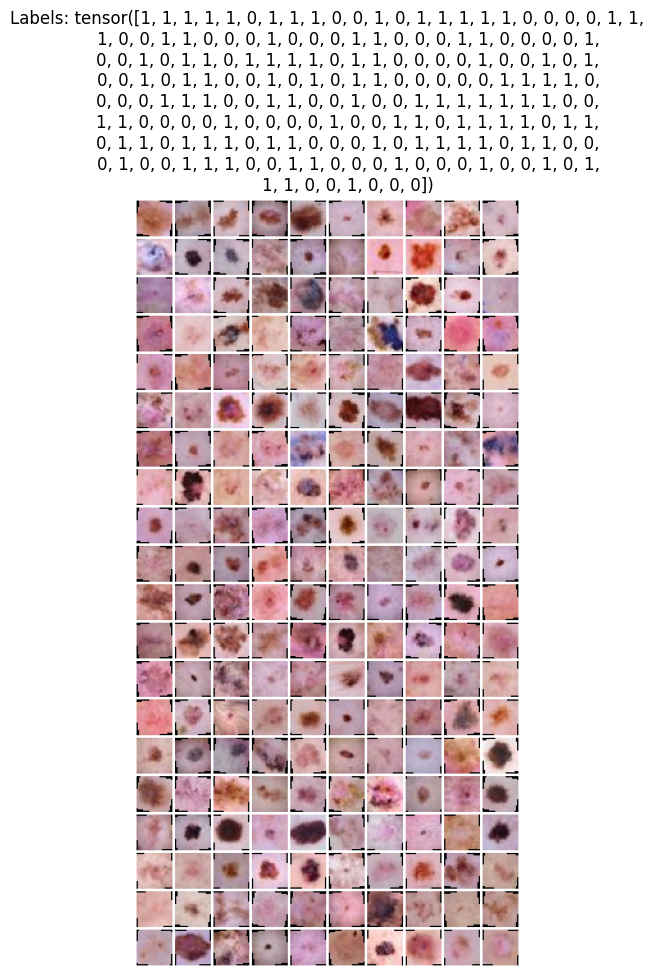

In [61]:
data_module = MedMNISTDataModule(hparams, transformacao)
data_module.setup()

check_dataloader = data_module.train_dataloader() # dataloader do treino
img_batch, label_batch = next(iter(check_dataloader))
print("Shape do batch:", img_batch.shape)

img_grid = make_grid(img_batch, nrow=10, pad_value=1)
fig = plt.figure(figsize=(10,10))
plt.imshow(img_grid.permute(1, 2, 0).numpy())
plt.title(f'Labels: {label_batch}')
plt.axis('off')
plt.show()

In [62]:
class TrainMNIST(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()

        self.save_hyperparameters(hparams)
        self.model = cnn_model
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)

        torchinfo.summary(self.model)

    def forward(self, x):
        return self.model(x).softmax(dim=-1)

    def classification_step(self, mode, batch):
        x, y = batch
        y_hat = self.forward(x)
        loss = self.loss(y_hat, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            _, preds = torch.max(y_hat, 1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step("train", train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step("val", val_batch)

    def configure_optimizers(self):
        optimizer = AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)

        return optimizer

In [63]:
debug = False  # Turn this True to test the code with a quick run

# Initialization
model = TrainMNIST(hparams)
data = MedMNISTDataModule(hparams, transformacao)

# The PL trainer can run various callbacks during training. Here we only use the
# callback that saves the weights of the trained network.
os.makedirs("logs", exist_ok=True)
checkpoint_callback = [ModelCheckpoint(dirpath="logs",  # path to save checkpoint
                                       filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
                                       monitor="val_acc",
                                       mode="max")]

trainer = pl.Trainer(max_epochs=hparams["max_epochs"], #devices=1, accelerator="gpu",
                     fast_dev_run=debug,
                     callbacks=checkpoint_callback,
                     log_every_n_steps=1
                     )

print("Hyperparameters:\n")
for k, v in hparams.items():
    print(f'{k}: {v}')

trainer.fit(model, data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Hyperparameters:

experiment_name: Test_Derma_1
max_epochs: 20
batch_size: 200
nworkers: 32
nout: 2
nin: 3
lr: 0.001
wd: 1e-05
cpu: False
Using downloaded and verified file: /home/vinicius/.medmnist/dermamnist.npz
Using downloaded and verified file: /home/vinicius/.medmnist/dermamnist.npz


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ EfficientNet       │  6.5 M │ train │     0 │
│ 1 │ loss     │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 6.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.5 M                                                                                                
Total estimated model params size (MB): 26                                                                         
Modules in train mode: 475                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=20` reached.


Using model logs/Test_Derma_1-epoch=18-val_acc=0.91.ckpt


/home/vinicius/.conda/envs/ML_Env/lib/python3.12/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


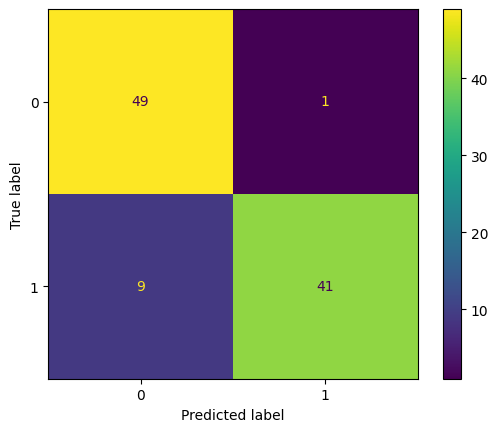

In [66]:
#baseline_model = random.choice(glob("logs/*.ckpt"))
baseline_model = "logs/Test_Derma_1-epoch=18-val_acc=0.91.ckpt"
print(f"Using model {baseline_model}")

# Load trained model
model = TrainMNIST.load_from_checkpoint(baseline_model).eval().cuda()

# Initialize validation data
data = MedMNISTDataModule(hparams, transformacao)
data.setup()
data.hparams.batch_size = 1
test_data = data.test_dataloader()

def collect_2d_results(data, model):
    y_trues = []
    y_labels = []
    for (img, label) in data:
        with torch.no_grad():
            out = model(img.cuda()).argmax(dim=-1).item()
        
        label = label.numpy()
        y_trues.append(label)
        y_labels.append(out)

    return y_trues, y_labels

y_trues_val, y_labels_val = collect_2d_results(test_data, model)

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_trues_val, y_labels_val, labels=np.arange(2)),
                                display_labels=np.arange(2))
fig = disp.plot(ax=None).figure_
plt.show()

## Parte 3 - Classificação com o DermaMNIST original (opcional para EA979)

### Exercício 3.1

Treine novamente o modelo final do exercício anterior, mas dessa vez utilize o conjunto original de dados do DermaMNIST (train_dataset_base, test_dataset_base).

**Note que o conjunto original de dados possui 7 classes distintas, mas estamos interessados apenas em duas classes: casos de carcinoma basocelular (label 1) e melanoma (label 4).** Portanto, você deve filtrar e organizar os dados para que eles sejam utilizados na classificação.

Verifique a quantidade de amostras de cada classe de interesse nos conjuntos de treino, validação e teste. Você deve notar que as duas classes estão desbalanceadas. Busque alternativas para lidar com esse desbalanceamento. Após aplicar as modificações os resultados da rede melhoraram?

Não se esqueça de comentar sobre os métodos utilizados e resultados obtidos, tentando justificar as decisões que foram tomadas.

---
Agora, utilizaremos o conjunto completo do DermaMNIST, com os conjuntos de  treino, validação e teste pré-defidos pelo pacote. 

Ao separar o conjunto de treino, percebe-se que existem 359 imagens de carcinoma basocelular e 779 imagens de melanoma. O desbalanço se mantém para os conjuntos de validação e teste. Para compensar o desbalanceamento entre as classes durente o treino, utilizei um 'Amostrador com peso', que carregará a mesma quantidade de imagens das duas classes em cada batch. Para isso, adicionei o WeightedRandomSampler no dataloader do conjunto de treino.

Para o treinamento, inicialmente, copiei a rede e os hiperparâmetros utilizados na rede anterior, obtendo-se 93% de acurácia no conjunto de validação e 92% no conjunto de teste (tested Derma_2). 
Após alguns testes mudando os hiperparâmetros, optei por testar uma técnica de redução de learning rate para melhorar a acurácia no final do treino, o melhor resultado obtido foi de 93% no conjunto de validação e 92% no conjunto de teste. (testes Derma_3).

Por fim, testei uma rede maior (efficientnet b3)

In [185]:
from torch.utils.data import WeightedRandomSampler
class MedMNISTDataModule(pl.LightningDataModule):
    def __init__(self, hparams, transform=None):
        super().__init__()
        self.save_hyperparameters(hparams)

        self.transform_treino = transform

        self.transform_val = transforms.Compose(
            [
                transforms.ToTensor()
            ])
    
    def prepare_data(self):
        DermaMNIST(split='train', download=True)
        DermaMNIST(split='val', download=True) # olhei no site do mnist e ess opção existe!!
        DermaMNIST(split='test', download=True)

    def setup(self, stage=None):
        train_dataset_base = DermaMNIST(split="train", download=False)
        val_dataset_base = DermaMNIST(split='val', download=False)
        test_dataset_base = DermaMNIST(split="test", download=False)

        if stage == "fit" or stage is None: #fit é treino e validacao
            
            train_indices_0 = train_dataset_base.labels == 1
            train_indices_1 = train_dataset_base.labels == 4
            val_indices_0 = val_dataset_base.labels == 1
            val_indices_1 = val_dataset_base.labels == 4
            print("Treino:")
            train_imgs_0 = train_dataset_base.imgs[train_indices_0.flatten(), :, :, :] # MODIFICADO PARA CARREGAR O DATASET INTEIRO
            n_t_c0 = train_imgs_0.shape[0]
            print("Número de imagens da classe 0: ", n_t_c0)
            train_imgs_1 = train_dataset_base.imgs[train_indices_1.flatten(), :, :, :]
            n_t_c1 = train_imgs_1.shape[0]

            print("Número de imagens da classe 1: ", train_imgs_1.shape[0])

            train_imgs = np.vstack([train_imgs_0, train_imgs_1])
            print("VALIDACAO:")
            val_imgs_0 = val_dataset_base.imgs[val_indices_0.flatten(), :, :, :]
            n_v_c0 = val_imgs_0.shape[0]
            print("Número de imagens da classe 0: ", n_v_c0)
            val_imgs_1 = val_dataset_base.imgs[val_indices_1.flatten(), :, :, :]
            n_v_c1 = val_imgs_1.shape[0]
            print("Número de imagens da classe 1: ", n_v_c1)
            val_imgs = np.vstack([val_imgs_0, val_imgs_1])

            train_labels = np.zeros(n_t_c0+n_t_c1).astype(int)
            train_labels[n_t_c0:].fill(1)

            val_labels = np.zeros(n_v_c0+n_v_c1).astype(int)
            val_labels[n_v_c0:].fill(1)

            self.train_dataset = DermaDataset(train_imgs, train_labels, transform=self.transform_treino)
            self.val_dataset = DermaDataset(val_imgs, val_labels, transform=self.transform_val)

        if stage == "test" or stage is None: # test é o teste :D
            test_indices_0 = test_dataset_base.labels == 1
            test_indices_1 = test_dataset_base.labels == 4
            print("TESTE:")
            test_imgs_0 = test_dataset_base.imgs[test_indices_0.flatten(), :, :, :]
            n_te_c0 = test_imgs_0.shape[0]
            print("Número de imagens da classe 0: ", n_te_c0)
            test_imgs_1 = test_dataset_base.imgs[test_indices_1.flatten(), :, :, :]
            n_te_c1 = test_imgs_1.shape[0]
            print("Número de imagens da classe 0: ", n_te_c1)
            test_imgs = np.vstack([test_imgs_0, test_imgs_1])

            test_labels = np.zeros(n_te_c0+n_te_c1).astype(int)
            test_labels[n_te_c0:].fill(1)

            self.test_dataset = DermaDataset(test_imgs, test_labels, transform=self.transform_val)


    '''
    Dataloaders optimize data loading and automatically prepare batches
    '''
    def train_dataloader(self):

        labels = self.train_dataset.labels
        contagem_de_cada_classe = np.bincount(labels)
        peso_por_classe = 1. / contagem_de_cada_classe
        peso_em_cada_amostra = [peso_por_classe[label] for label in labels]
        amostragem = WeightedRandomSampler(
            weights=peso_em_cada_amostra,
            num_samples=len(peso_em_cada_amostra),
            replacement=True
        )


        return DataLoader(self.train_dataset, 
                            batch_size=self.hparams.batch_size, 
                            num_workers=self.hparams.nworkers, 
                            sampler=amostragem,
                            persistent_workers=True,
                            pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, 
                          batch_size=self.hparams.batch_size, 
                          num_workers=self.hparams.nworkers, 
                          shuffle=False,
                          persistent_workers=True,
                          pin_memory=True)

    def test_dataloader(self):
        return DataLoader(self.test_dataset,
                          batch_size = self.hparams.batch_size,
                          num_workers = self.hparams.nworkers,
                          shuffle = False,
                          persistent_workers = True,
                          pin_memory = True)

In [191]:
import torch.optim.lr_scheduler as lr_scheduler
class TrainMNIST(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()

        self.save_hyperparameters(hparams)
        self.model = cnn_model
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)

        torchinfo.summary(self.model)

    def forward(self, x):
        return self.model(x).softmax(dim=-1)
    
    def classification_step(self, mode, batch):
        x, y = batch
        y_hat = self.forward(x)
        loss = self.loss(y_hat, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            _, preds = torch.max(y_hat, 1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step("train", train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step("val", val_batch)

    def configure_optimizers(self):
        optimizer = AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)
        scheduler = lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.1, patience=5, min_lr=1e-6, threshold=1e-2 
        )
        return {"optimizer": optimizer, 
                "lr_scheduler": {
                    "scheduler":scheduler,
                    "monitor": "val_loss",
                    "frequency": 1
        }}

In [ ]:
hparams = {"experiment_name": "Test_Derma_3",  # experiment name identifies the run for later
           "max_epochs": 100,  # number of epochs to train
           "batch_size": 500,  # size of batch
           "nworkers": 0 if sys.platform.startswith("win") else mp.cpu_count(),  # number of workers to use in parallel loading
           "nout": 2,  # number of classes
           "nin": 3,  # USANDO TRES CANAIS
           "lr": 1e-3,  # learning rate
           "wd": 1e-5,  # weight decay for optimizer
           "cpu": False,  # forces using the CPU
           }
for k, v in hparams.items():
    print(f"{k}: {v}")

transformacao = transforms.Compose([
            transforms.ToTensor(), # Essencial para preparar a imagem para a rede neural
            transforms.RandomHorizontalFlip(), # Exemplo de Data Augmentation
            transforms.RandomRotation(12)
        ])

cnn_model = models.efficientnet_b1(weights=True)
print('-'*60)
# por padrão a efficientnet já espera uma imagem de tres canais na entrada, portanto vamos mudar a saida, definida em um bloco chamado 'classifier'
print(cnn_model.classifier)
cnn_model.classifier[1] = nn.Linear(in_features=cnn_model.classifier[1].in_features, out_features=2)
print(cnn_model.classifier)

experiment_name: Test_Derma_3
max_epochs: 100
batch_size: 500
nworkers: 32
nout: 2
nin: 3
lr: 0.001
wd: 1e-05
cpu: False
------------------------------------------------------------
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


/home/vinicius/.conda/envs/ML_Env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B1_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Treino:
Número de imagens da classe 0:  359
Número de imagens da classe 1:  779
VALIDACAO:
Número de imagens da classe 0:  52
Número de imagens da classe 1:  111
TESTE:
Número de imagens da classe 0:  103
Número de imagens da classe 0:  223
Shape do batch: torch.Size([500, 3, 28, 28])


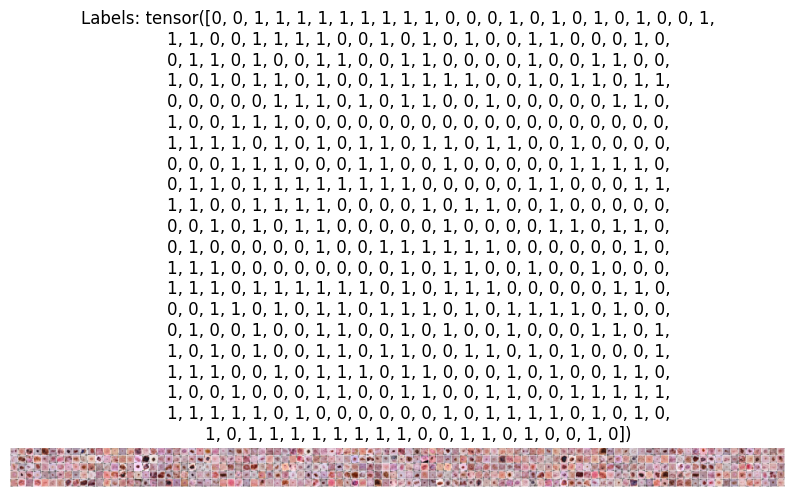

In [193]:
data_module = MedMNISTDataModule(hparams, transformacao)
data_module.setup()

check_dataloader = data_module.train_dataloader() # dataloader do treino
img_batch, label_batch = next(iter(check_dataloader))
print("Shape do batch:", img_batch.shape)

img_grid = make_grid(img_batch, nrow=100, pad_value=1)
fig = plt.figure(figsize=(10,10))
plt.imshow(img_grid.permute(1, 2, 0).numpy())
plt.title(f'Labels: {label_batch}')
plt.axis('off')
plt.show()

In [194]:
debug = False  # Turn this True to test the code with a quick run

# Initialization
model = TrainMNIST(hparams)
data = MedMNISTDataModule(hparams, transformacao)

# The PL trainer can run various callbacks during training. Here we only use the
# callback that saves the weights of the trained network.
os.makedirs("logs", exist_ok=True)
checkpoint_callback = [ModelCheckpoint(dirpath="logs",  # path to save checkpoint
                                       filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
                                       monitor="val_acc",
                                       mode="max")]

trainer = pl.Trainer(max_epochs=hparams["max_epochs"], #devices=1, accelerator="gpu",
                     fast_dev_run=debug,
                     callbacks=checkpoint_callback,
                     log_every_n_steps=1
                     )

print("Hyperparameters:\n")
for k, v in hparams.items():
    print(f'{k}: {v}')

trainer.fit(model, data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/vinicius/.conda/envs/ML_Env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/vinicius/2026s1-pi05-cnn-VBassete/logs exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Hyperparameters:

experiment_name: Test_Derma_3
max_epochs: 100
batch_size: 500
nworkers: 32
nout: 2
nin: 3
lr: 0.001
wd: 1e-05
cpu: False
Using downloaded and verified file: /home/vinicius/.medmnist/dermamnist.npz
Using downloaded and verified file: /home/vinicius/.medmnist/dermamnist.npz
Using downloaded and verified file: /home/vinicius/.medmnist/dermamnist.npz
Treino:
Número de imagens da classe 0:  359
Número de imagens da classe 1:  779
VALIDACAO:
Número de imagens da classe 0:  52
Número de imagens da classe 1:  111


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ EfficientNet       │  6.5 M │ train │     0 │
│ 1 │ loss     │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 6.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.5 M                                                                                                
Total estimated model params size (MB): 26                                                                         
Modules in train mode: 475                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=100` reached.


Using model logs/Test_Derma_2-epoch=19-val_acc=0.93.ckpt


/home/vinicius/.conda/envs/ML_Env/lib/python3.12/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Treino:
Número de imagens da classe 0:  359
Número de imagens da classe 1:  779
VALIDACAO:
Número de imagens da classe 0:  52
Número de imagens da classe 1:  111
TESTE:
Número de imagens da classe 0:  103
Número de imagens da classe 0:  223


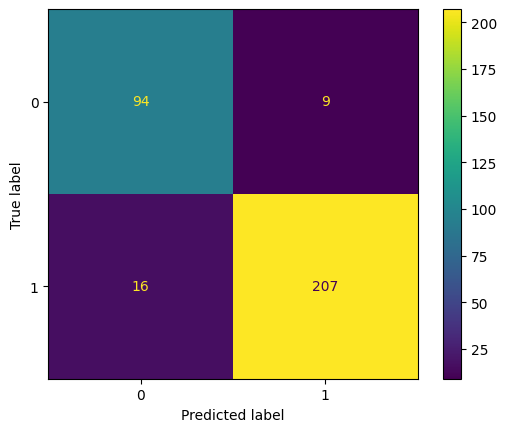

In [198]:
baseline_model = "logs/Test_Derma_2-epoch=19-val_acc=0.93.ckpt"
print(f"Using model {baseline_model}")

# Load trained model
model = TrainMNIST.load_from_checkpoint(baseline_model).eval().cuda()

# Initialize validation data
data = MedMNISTDataModule(hparams, transformacao)
data.setup()
data.hparams.batch_size = 1
test_data = data.test_dataloader()

def collect_2d_results(data, model):
    y_trues = []
    y_labels = []
    for (img, label) in data:
        with torch.no_grad():
            out = model(img.cuda()).argmax(dim=-1).item()
        
        label = label.numpy()
        y_trues.append(label)
        y_labels.append(out)

    return y_trues, y_labels

y_trues_val, y_labels_val = collect_2d_results(test_data, model)

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_trues_val, y_labels_val, labels=np.arange(2)),
                                display_labels=np.arange(2))
fig = disp.plot(ax=None).figure_
plt.show()